In [13]:
# load packages
import os
import warnings
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt


from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback, EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

while not os.getcwd().endswith("GGSpeciale"):
    os.chdir("..")

os.chdir("code/SPID_code")
from gmDAGGER import train_spid
from PySRWrapper_safe import PySRPolicy

os.chdir("../../Simglucose_suite")

# Comparison of training settings and test settings 

* Load teacher results
* Load student results
* Plot reward, TRI and CFR before and after for teacher and studen respectively



In [14]:
teacher_dirs = {
    "open": Path("./models/open_optuna_optimal/clarke_risk"),
    "closed": Path("./models/closed_hist_optuna_optimal_2/clarke_risk"),
}

eval_test_file = "logs/eval/eval_log/metrics_log.csv"
eval_validate_file = "logs/eval_stress_test/eval_log/metrics_log.csv"

teacher_dfs = []

for (teacher_type, teacher_dir) in teacher_dirs.items():
    for patient in teacher_dir.iterdir():

        try:
            eval_test = pd.read_csv(patient / eval_test_file)
            eval_validate = pd.read_csv(patient / eval_validate_file)
        except:
            continue

        row = pd.concat(
            {"test": eval_test, "validate": eval_validate},
            axis=1,
        )

        row.index = pd.MultiIndex.from_tuples(
            [(teacher_type, patient.name)] * len(row),
            names=["model", "patient"],
        )

        print(teacher_type, patient.name)

        teacher_dfs.append(row)

teacher_df = pd.concat(teacher_dfs).sort_index(ascending=[False, True])


open adult-004
open adult-009
open adult-003
open adult-010
open adult-007
open adult-002
open adult-008
open adult-005
open adult-001
open adult-006
closed adult-001
closed adult-006
closed adult-008
closed adult-002
closed adult-005
closed adult-007
closed adult-004
closed adult-003
closed adult-009
closed adult-010


In [15]:
teacher_df

test                                             \
                 eval_index    TBR_II      TBR_I        TIR      TAR_I   
model  patient                                                           
open   adult-001          0  0.635728   3.214721  93.015584   3.769695   
       adult-002          0  1.680473   9.251220  86.844912   3.903868   
       adult-003          0  0.231438   2.540325  90.147806   7.311868   
       adult-004          0  0.168073   8.035622  80.756884  11.207494   
       adult-005          0  0.366838   2.262037  79.290886  18.447077   
       adult-006          0  1.428605   5.630793  72.740366  21.628842   
       adult-007          0  1.936940  10.544516  75.185441  14.270043   
       adult-008          0  0.060335   1.106378  97.922452   0.971170   
       adult-009          0  0.310620   3.317391  92.565658   4.116951   
       adult-010          0  1.056561   5.279025  83.441856  11.279119   
closed adult-001          0  0.357914   3.258734  88.781542   7.959724   
       adult-002          0  0.181821   4.000805  88.721143   7.278052   
       adult-003          0  0.125776   1.803775  92.815975   5.380250   
       adult-004          0  5.959806  10.672211  31.115731  58.212058   
       adult-005          0  0.343386   2.479229  89.051368   8.469403   
       adult-006          0  0.991159   5.478648  74.145473  20.375879   
       adult-007          0  0.031149   3.153320  86.432685  10.413995   
       adult-008          0  0.275116   1.383396  98.487643   0.128961   
       adult-009          0  0.145761   2.108170  95.203682   2.688147   
       adult-010          0  0.413432   3.290857  85.569398  11.139745   

                                                                 \
                     TAR_II total_daily_insulin average_insulin   
model  patient                                                    
open   adult-001   0.007732                 0.0             NaN   
       adult-002   0.000000                 0.0             NaN   
       adult-003   0.004707                 0.0             NaN   
       adult-004   0.504218                 0.0             NaN   
       adult-005   1.034693                 0.0             NaN   
       adult-006   1.471579                 0.0             NaN   
       adult-007   0.692660                 0.0             NaN   
       adult-008   0.000000                 0.0             NaN   
       adult-009   0.000000                 0.0             NaN   
       adult-010   0.116241                 0.0             NaN   
closed adult-001   0.016306                 0.0             NaN   
       adult-002   0.000000                 0.0             NaN   
       adult-003   0.000000                 0.0             NaN   
       adult-004  32.571033                 0.0             NaN   
       adult-005   0.000000                 0.0             NaN   
       adult-006   0.665919                 0.0             NaN   
       adult-007   0.016661                 0.0             NaN   
       adult-008   0.000000                 0.0             NaN   
       adult-009   0.000000                 0.0             NaN   
       adult-010   0.053754                 0.0             NaN   

                                                         ...  \
                 TBR_II_episode_mean TBR_II_episode_std  ...   
model  patient                                           ...   
open   adult-001            0.635728           1.677011  ...   
       adult-002            1.680533           2.235796  ...   
       adult-003            0.231482           0.916969  ...   
       adult-004            0.168073           0.769989  ...   
       adult-005            0.366836           1.047259  ...   
       adult-006            1.428588           2.002132  ...   
       adult-007            1.936991           2.865566  ...   
       adult-008            0.060335           0.433814  ...   
       adult-009            0.310626           1.182266  ...   
       adu

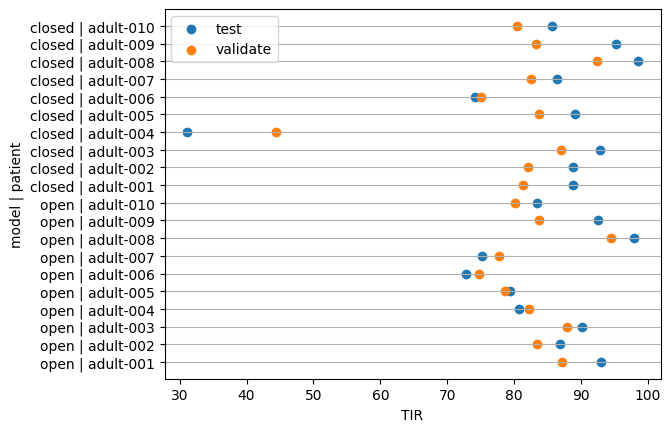

In [16]:
plot_df = teacher_df.copy()

y_labels = [
    f"{model} | {patient}"
    for model, patient in plot_df.index
]

plt.scatter(plot_df[("test", "TIR")], y_labels, label="test")
plt.scatter(plot_df[("validate", "TIR")], y_labels, label="validate")

plt.grid(axis="y")
plt.legend()
plt.xlabel("TIR")
plt.ylabel("model | patient")
plt.show()

In [17]:
# plt.scatter(teacher_df.test["critical_failure_rate"] - teacher_df.test["critical_failure_rate"], teacher_df.index, label= "train")
# plt.scatter(teacher_df.validate["critical_failure_rate"] - teacher_df.test["critical_failure_rate"], teacher_df.index, label= "validate")
# plt.grid(axis="y")
# plt.legend()

/tmp/ipykernel_501621/3011532606.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


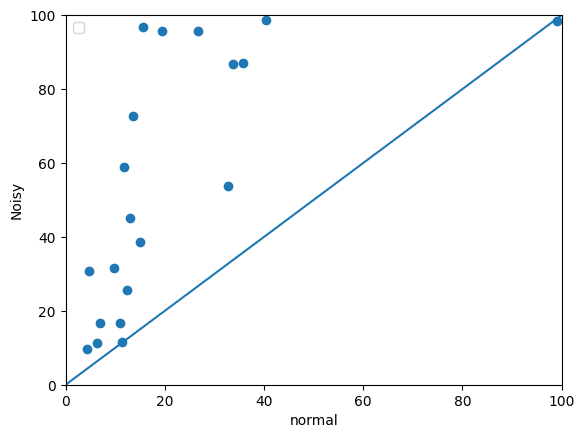

In [18]:
plt.scatter(teacher_df.test["critical_failure_rate"], teacher_df.validate["critical_failure_rate"])
plt.axline((50,50), (60,60))
plt.xlabel("normal")
plt.ylabel("Noisy")
plt.xlim(0, 100)
plt.ylim(0,100)
plt.legend()

In [19]:
student_dirs = {"open" : Path("./distilled_final_5/open/square_threshold_15/"), "closed" : Path("./distilled_final_5/closed/linear_10/")}

# student_dir = Path("./distilled_final_5/closed/linear_10/")


eval_test_file = "./distilled_eval/eval_log/metrics_log.csv"
eval_validate_file = "./logs/eval_stress_test/eval_log/metrics_log.csv"

student_df = pd.DataFrame()

for student_type, student_dir in student_dirs.items():
    for patient in student_dir.iterdir():

        for run in patient.iterdir():

            if run.is_dir():


                try:
                    eval_test = pd.read_csv(str(run / f"clarke_risk/{patient.name}" / eval_test_file))
                    eval_validate = pd.read_csv(run / f"clarke_risk/{patient.name}" /eval_validate_file)
                except Exception as e:
                    print(e)
                    continue

                row = pd.concat(
                    {"test": eval_test, "validate": eval_validate},
                    axis=1,
                )

                row.index = pd.MultiIndex.from_tuples(
                    [(student_type, patient.name, run.name)] * len(row),
                    names=["model", "patient", "run"],
                )

                student_df = pd.concat([student_df, row])


student_df =  student_df.sort_index(ascending=[True, True, True])

[Errno 2] No such file or directory: 'distilled_final_5/open/square_threshold_15/adult-004/run_02/clarke_risk/adult-004/logs/eval_stress_test/eval_log/metrics_log.csv'
[Errno 2] No such file or directory: 'distilled_final_5/open/square_threshold_15/adult-004/run_00/clarke_risk/adult-004/logs/eval_stress_test/eval_log/metrics_log.csv'
[Errno 2] No such file or directory: 'distilled_final_5/open/square_threshold_15/adult-003/run_01/clarke_risk/adult-003/logs/eval_stress_test/eval_log/metrics_log.csv'
[Errno 2] No such file or directory: 'distilled_final_5/open/square_threshold_15/adult-003/run_02/clarke_risk/adult-003/logs/eval_stress_test/eval_log/metrics_log.csv'


In [20]:
student_df.head()

test                                            \
                        eval_index    TBR_II      TBR_I        TIR     TAR_I   
model  patient   run                                                           
closed adult-001 run_00          0  0.742393   3.422813  95.107535  1.469651   
                 run_01          0  8.699168  23.879390  76.120610  0.000000   
                 run_02          0  0.372323   2.340656  97.249077  0.410267   
                 run_03          0  0.668186   3.340021  94.322236  2.337743   
                 run_04          0  0.572357   2.782664  91.092276  6.125060   

                                                                    \
                        TAR_II total_daily_insulin average_insulin   
model  patient   run                                                 
closed adult-001 run_00    0.0                 0.0             NaN   
                 run_01    0.0                 0.0             NaN   
                 run_02    0.0                 0.0             NaN   
                 run_03    0.0                 0.0             NaN   
                 run_04    0.0                 0.0             NaN   

                                                                ...  \
                        TBR_II_episode_mean TBR_II_episode_std  ...   
model  patient   run                                            ...   
closed adult-001 run_00            0.742389           1.998769  ...   
                 run_01            8.698795           4.191598  ...   
                 run_02            0.372323           1.790430  ...   
                 run_03            0.668186           1.815698  ...   
                 run_04            0.572357           1.705858  ...   

                                                validate  \
                        critical_failure_rate_ci95_upper   
model  patient   run                                       
closed adult-001 run_00                        99.056850   
                 run_01                       100.000000   
                 run_02                        99.635549   
                 run_03                        99.456679   
                 run_04                        99.456679   

                                                                        \
                        critical_failure_count completed_episode_count   
model  patient   run                                                     
closed adult-001 run_00                    293                       7   
                 run_01                    300                       0   
                 run_02                    296                       4   
                 run_03                    295                       5   
                 run_04                    295                       5   

                                                                         \
                        survivors num_timesteps mean_reward  std_reward   
model  patient   run                                                      
closed adult-001 run_00         7           NaN  502.760401  236.214844   
                 run_01         0           NaN  159.564004   93.982094   
                 run_02         4           NaN  466.121072  164.956340   
                 run_03         5           NaN  454.789108  225.692836   
                 run_04         5           NaN  476.655134  248.190547   

                                                                   \
                        reward_ti90_95_lower reward_ti90_95_upper   
model  patient   run                                                
closed adult-001 run_00           247.889984          1111.165161   
                 run_01            68.815071           380.271606   
                 run_02           275.255463           881.994141   
                 run_03           224.494415           902.456299   
                 run_04           224.081406          1127.594971   

                               

In [21]:
test_df = student_df["test"]

best_idx = (
    test_df
    .groupby(level=["model", "patient"])["mean_reward"]
    .idxmax()
)

best_student_df = student_df.loc[best_idx]

df = best_student_df.reset_index()

In [22]:
test_df = df.set_index(["model", "patient"])

test_df

run       test                                  \
                         eval_index    TBR_II      TBR_I        TIR   
model  patient                                                        
closed adult-001  run_02          0  0.372323   2.340656  97.249077   
       adult-002  run_00          0  0.021507   2.788750  89.714601   
       adult-003  run_04          0  0.523909   8.242827  76.270270   
       adult-004  run_00          0  0.031822   1.103859  69.050936   
       adult-005  run_04          0  0.144041   2.091789  94.161723   
       adult-006  run_03          0  0.224353   1.898024  67.879418   
       adult-007  run_03          0  0.669804   9.544272  85.876704   
       adult-008  run_04          0  0.090300   0.914901  99.053599   
       adult-009  run_04          0  0.403571   6.809908  92.870246   
       adult-010  run_01          0  0.314143   2.903724  95.534732   
open   adult-001  run_03          0  0.210902   2.063991  94.189302   
       adult-002  run_00          0  0.138111   3.383729  85.805380   
       adult-003  run_03          0  0.546232   3.750899  86.067524   
       adult-004  run_01          0  0.451169  18.435831  73.246435   
       adult-005  run_03          0  0.174228   1.260587  75.149887   
       adult-006  run_02          0  1.542280   5.246777  73.879516   
       adult-007  run_00          0  1.199322   7.911100  79.101375   
       adult-008  run_01          0  0.000000   0.185575  99.643500   
       adult-009  run_03          0  0.205042   0.943052  93.685120   
       adult-010  run_01          0  1.021356   4.773727  81.003997   

                                                                           \
                      TAR_I    TAR_II total_daily_insulin average_insulin   
model  patient                                                              
closed adult-001   0.410267  0.000000                 0.0             NaN   
       adult-002   7.496648  0.000000                 0.0             NaN   
       adult-003  15.486902  1.788773                 0.0             NaN   
       adult-004  29.845205  4.456450                 0.0             NaN   
       adult-005   3.746488  0.000000                 0.0             NaN   
       adult-006  30.222558  1.896529                 0.0             NaN   
       adult-007   4.579024  0.000000                 0.0             NaN   
       adult-008   0.031500  0.000000                 0.0             NaN   
       adult-009   0.319846  0.000000                 0.0             NaN   
       adult-010   1.561545  0.000000                 0.0             NaN   
open   adult-001   3.746707  0.000000                 0.0             NaN   
       adult-002  10.810890  0.000000                 0.0             NaN   
       adult-003  10.181577  0.149404                 0.0             NaN   
       adult-004   8.317734  0.083678                 0.0             NaN   
       adult-005  23.589526  2.172719                 0.0             NaN   
       adult-006  20.873707  0.714439                 0.0             NaN   
       adult-007  12.987526  0.187695                 0.0             NaN   
       adult-008   0.170925  0.000000                 0.0             NaN   
       adult-009   5.371827  0.000000                 0.0             NaN   
       adult-010  14.222276  0.220015                 0.0             NaN   

                                      ...                         validate  \
                 TBR_II_episode_mean  ... critical_failure_rate_ci95_upper   
model  patient                        ...                                    
closed adult-001            0.372323  ...                        99.635549   
       adult-002            0.021507  ...                        73.874652   
       adult-003            0.523909  ...                        96.921168   
       adult-004            0.031852  ...                        52.155014   
       adult-005            0.144040  ...                        84.0

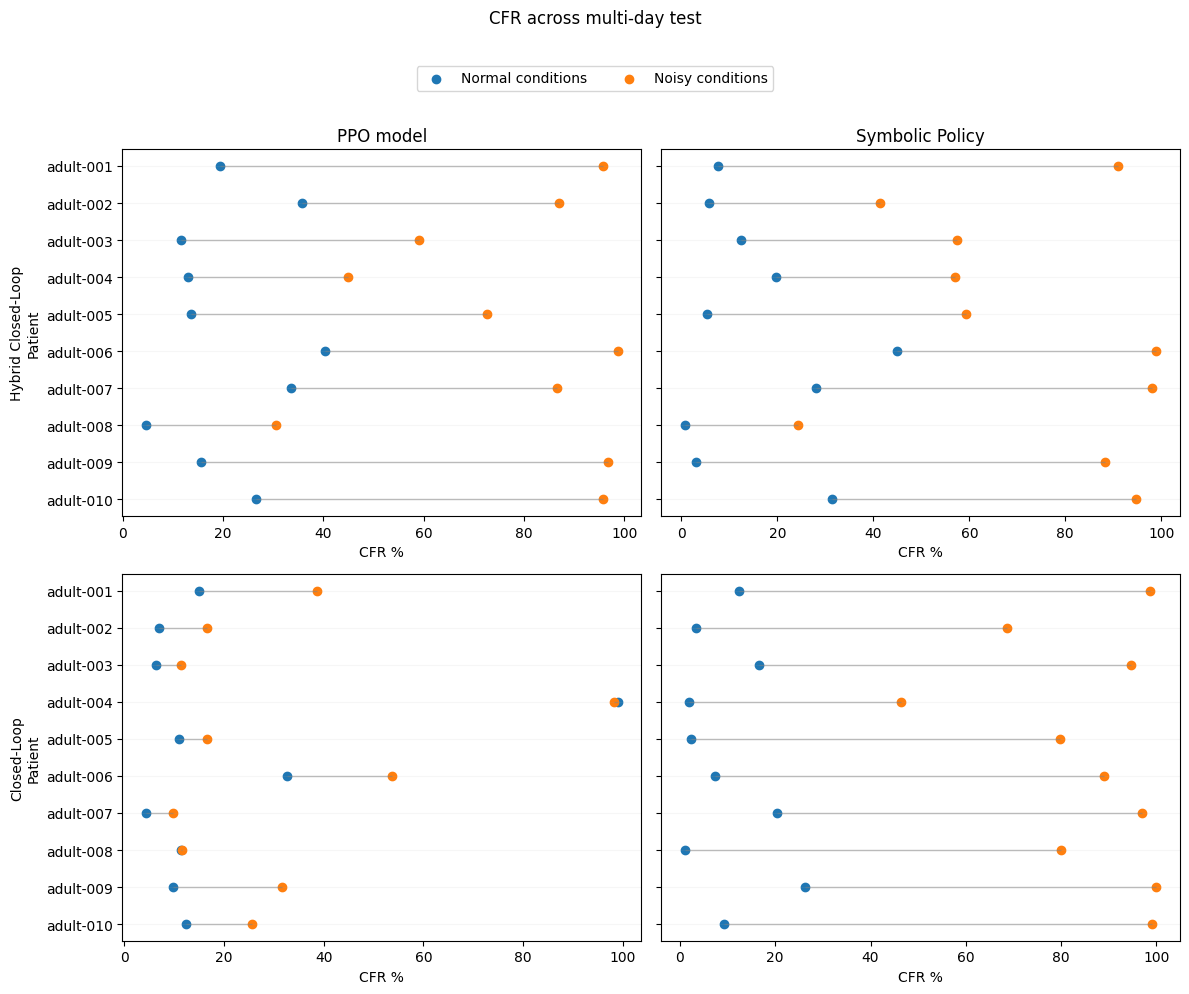

In [26]:
col_name = "critical_failure_rate"

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    sharex=False,
    sharey="row",
    figsize=(12, 10)
)

models = ["open", "closed"]
model_titles = {
    "open": "Hybrid Closed-Loop",
    "closed": "Closed-Loop",
}

def plot_panel(ax, plot_df, title=None, ylabel=None, show_legend=False):
    x_test = plot_df[("test", col_name)]
    x_validate = plot_df[("validate", col_name)]
    y = plot_df.index

    ax.scatter(x_test, y, label="Normal conditions")
    ax.scatter(x_validate, y, label="Noisy conditions")

    ax.hlines(
        y=y,
        xmin=x_test,
        xmax=x_validate,
        linewidth=1,
        alpha=0.5,
        color="grey"
    )

    ax.grid(axis="y", alpha=0.1)
    ax.set_xlabel("CFR %")

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    if title is not None:
        ax.set_title(title)

    if show_legend:
        ax.legend()


for row_idx, model_name in enumerate(models):

    # -------------------------
    # Left column: PPO / teacher
    # -------------------------
    teacher_plot_df = (
        teacher_df
        .loc[model_name]
        .copy()
    )

    # after .loc[model_name], index is patient
    teacher_plot_df = teacher_plot_df.sort_index(ascending=False)

    plot_panel(
        axes[row_idx, 0],
        teacher_plot_df,
        title="PPO model" if row_idx == 0 else None,
        ylabel=f"{model_titles[model_name]}\nPatient",
    )

    # -------------------------
    # Right column: Symbolic / student
    # -------------------------
    student_plot_df = (
        df
        .set_index(["model", "patient"])
        .loc[model_name]
        .copy()
    )

    # after .loc[model_name], index is patient
    student_plot_df = student_plot_df.sort_index(ascending=False)

    plot_panel(
        axes[row_idx, 1],
        student_plot_df,
        title="Symbolic Policy" if row_idx == 0 else None,
    )


fig.legend(
    handles=axes[0, 0].get_legend_handles_labels()[0],
    labels=axes[0, 0].get_legend_handles_labels()[1],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=2
)

fig.suptitle("CFR across multi-day test", y=0.99)

fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()